In [25]:
import pandas as pd
datafile=pd.read_csv ("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/sleep.csv")
datafile.groupby('group').describe()

A                                                extra        ...  \
      count  mean      std   min    25%   50%    75%   max count  mean  ...   
group                                                                   ...   
1      10.0   5.5  3.02765   1.0   3.25   5.5   7.75  10.0  10.0  0.75  ...   
2      10.0  15.5  3.02765  11.0  13.25  15.5  17.75  20.0  10.0  2.33  ...   

                    ID                                            
        75%  max count mean      std  min   25%  50%   75%   max  
group                                                             
1      1.70  3.7  10.0  5.5  3.02765  1.0  3.25  5.5  7.75  10.0  
2      4.15  5.5  10.0  5.5  3.02765  1.0  3.25  5.5  7.75  10.0  

[2 rows x 24 columns]

In [26]:
!mamba install pandas

/bin/bash: line 1: mamba: command not found


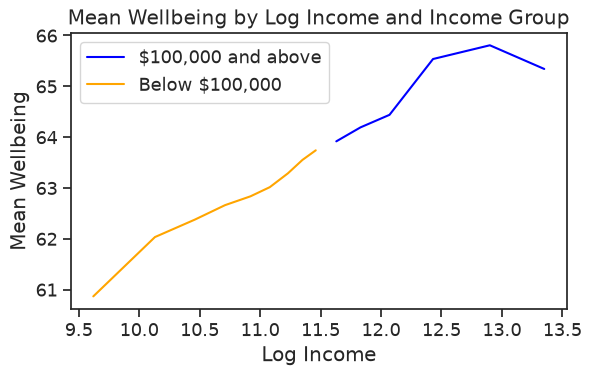

In [27]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
source=pd.read_csv ("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/Income2023.csv")
# Aggregate at each observed income value for a readable reproduction of the fitted relationships.
figure_2 = (source.groupby(['income_above_100','income','log_income'], as_index=False)
            .agg(mean_wellbeing=('wellbeing','mean'), n=('wellbeing','size')))
figure_2['income_group'] = np.where(figure_2['income_above_100'].eq(1), '$100,000 and above', 'Below $100,000')
figure_2 = figure_2.sort_values(['income_group','log_income'])
plt.figure(figsize=(6, 4))
plt.plot(figure_2.query("income_group == '$100,000 and above'")['log_income'],
         figure_2.query("income_group == '$100,000 and above'")['mean_wellbeing'], label='$100,000 and above', color='blue')
plt.plot(figure_2.query("income_group == 'Below $100,000'")['log_income'],
         figure_2.query("income_group == 'Below $100,000'")['mean_wellbeing'], label='Below $100,000', color='orange')
plt.xlabel('Log Income')
plt.ylabel('Mean Wellbeing')
plt.title('Mean Wellbeing by Log Income and Income Group')
plt.legend()
plt.tight_layout()
#plt.savefig("C:\\2023_income_wellbeing.png", dpi=300)
plt.show()

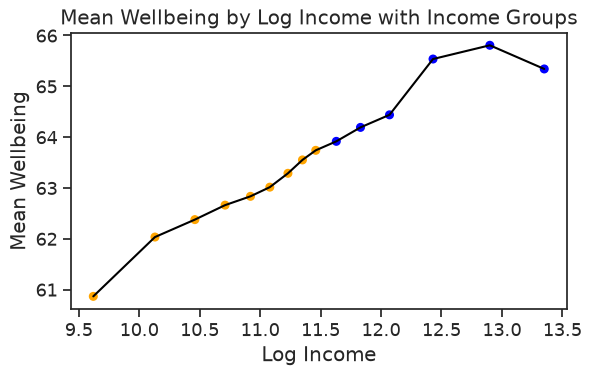

In [28]:
figure_2 = figure_2.sort_values('log_income')

plt.figure(figsize=(6, 4))
plt.plot(figure_2['log_income'], figure_2['mean_wellbeing'],
         color='black', linewidth=1.5)

# Optional: add colored points for groups
plt.scatter(figure_2['log_income'], figure_2['mean_wellbeing'],
            c=figure_2['income_group'].map({
                '$100,000 and above': 'blue',
                'Below $100,000': 'orange'
            }),
            s=30)
plt.xlabel('Log Income')
plt.ylabel('Mean Wellbeing')
plt.title('Mean Wellbeing by Log Income with Income Groups')
plt.tight_layout()
#plt.savefig("C:\\income_wellbeing1.png", dpi=300)
plt.show()

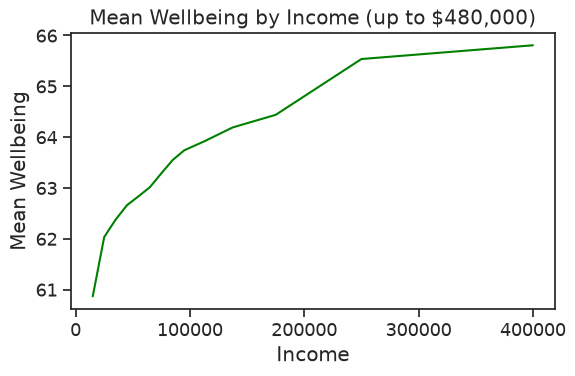

In [29]:
plot_data = (figure_2.loc[figure_2['income'] <= 480000]
             .groupby('income', as_index=False)
             .agg(mean_wellbeing=('mean_wellbeing','mean'), n=('n','sum'))
             .sort_values('income'))
plt.figure(figsize=(6, 4))
plt.plot(plot_data['income'], plot_data['mean_wellbeing'], color='green')
plt.xlabel('Income')
plt.ylabel('Mean Wellbeing')
plt.title('Mean Wellbeing by Income (up to $480,000)')
plt.tight_layout()
plt.show()

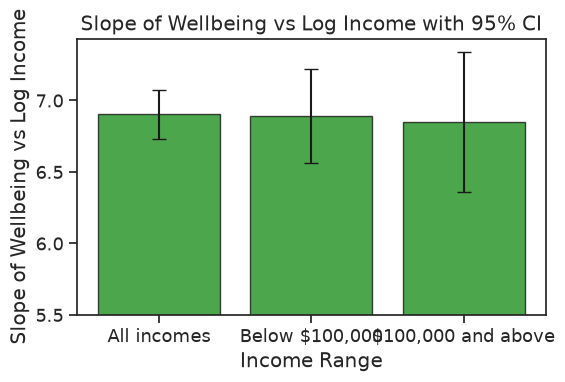

In [30]:
rows=[]
for label, d in [('All incomes', source), ('Below $100,000', source[source['income_above_100']==0]), ('$100,000 and above', source[source['income_above_100']==1])]:
    x=d['log_income'].to_numpy(); y=d['wellbeing'].to_numpy()
    X=np.column_stack([np.ones(len(d)), x])
    coef=np.linalg.lstsq(X,y,rcond=None)[0]
    residual=y-X@coef
    se=np.sqrt((residual@residual/(len(d)-2))*np.linalg.inv(X.T@X)[1,1])
    rows.append({'income_range':label,'slope':coef[1],'standard_error':se,'n':len(d),'r_squared':1-(residual@residual)/((y-y.mean())@(y-y.mean()))})
table_1=pd.DataFrame(rows)
table_1['ci_lower']=table_1['slope']-1.96*table_1['standard_error']
table_1['ci_upper']=table_1['slope']+1.96*table_1['standard_error']
plt.figure(figsize=(6, 4))
plt.bar(table_1['income_range'], bottom=5.5, height=table_1['slope'],
                 yerr=1.96*table_1['standard_error'], capsize=5, color='green', alpha=0.7, edgecolor='black')
#plt.errorbar(table_1['income_range'], table_1['slope'],
#                yerr=1.96*table_1['standard_error'], fmt='o', capsize=5, color='purple')
plt.xlabel('Income Range')
plt.ylabel('Slope of Wellbeing vs Log Income')
plt.title('Slope of Wellbeing vs Log Income with 95% CI')
plt.tight_layout()
plt.show()

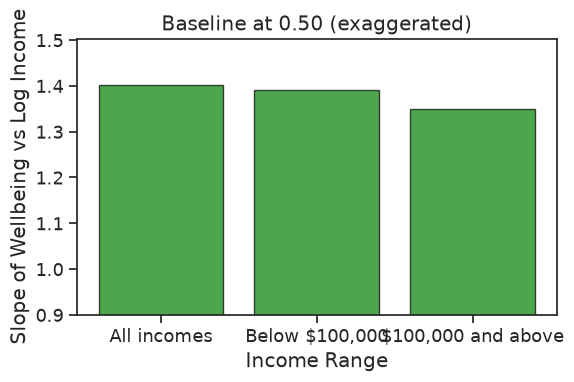

In [31]:
plt.figure(figsize=(6,4))
plt.bar(table_1['income_range'], table_1['slope'],
        capsize=5, color='green', alpha=0.7, edgecolor='black')
plt.ylim(0.9, table_1['slope'].max() + .1)
plt.title("Baseline at 0.50 (exaggerated)")
plt.xlabel("Income Range")
plt.ylabel("Slope of Wellbeing vs Log Income")
plt.tight_layout()
plt.show()

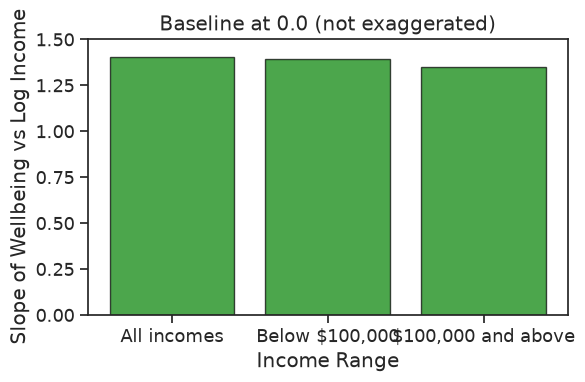

In [32]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(table_1['income_range'], table_1['slope'],
        capsize=5, color='green', alpha=0.7, edgecolor='black')
plt.ylim(0.0, table_1['slope'].max() + .1)
plt.title("Baseline at 0.0 (not exaggerated)")
plt.xlabel("Income Range")
plt.ylabel("Slope of Wellbeing vs Log Income")
plt.tight_layout()
plt.show()


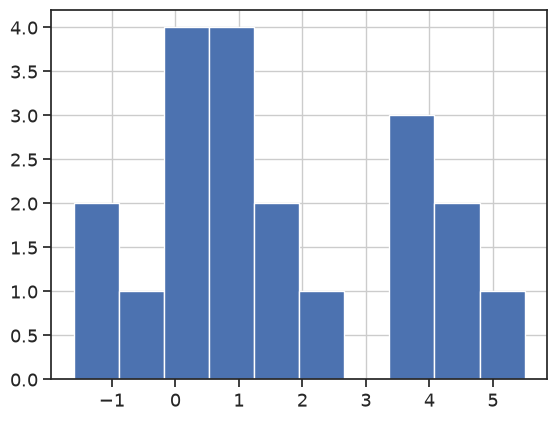

In [33]:
datafile["extra"].hist()
plt.show()

<Axes: ylabel='Density'>

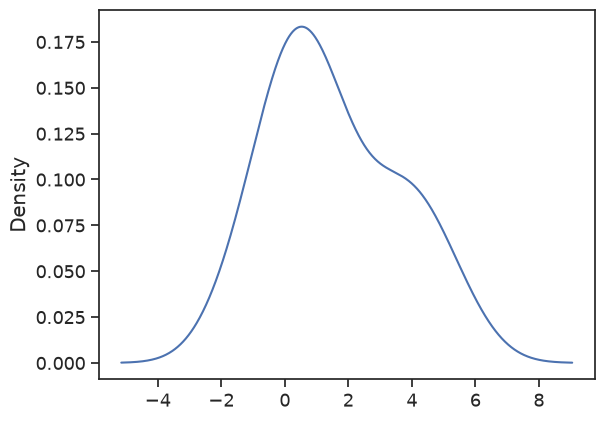

In [34]:
datafile["extra"].plot(kind="density")

<Axes: >

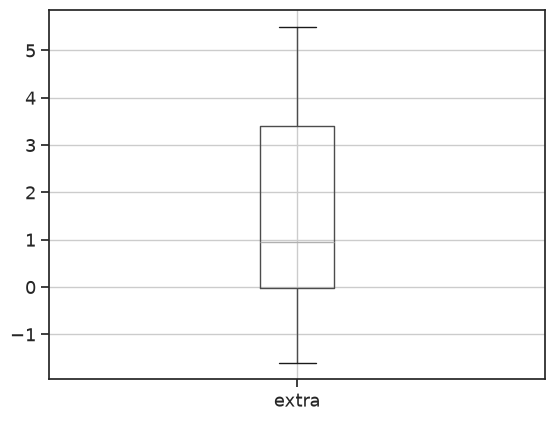

In [35]:
datafile.boxplot(column="extra")

<Axes: ylabel='Frequency'>

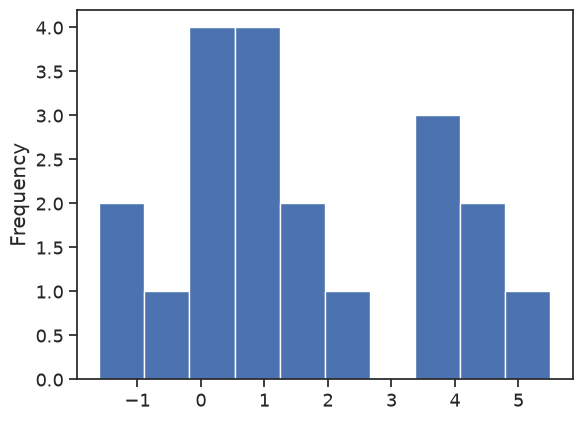

In [36]:
# Histogram
datafile["extra"].plot(kind="hist")

<Axes: ylabel='Density'>

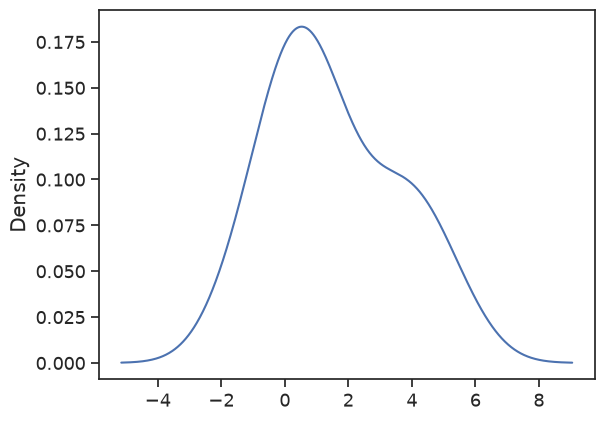

In [37]:
# Density curve
datafile["extra"].plot(kind="density")

<Axes: >

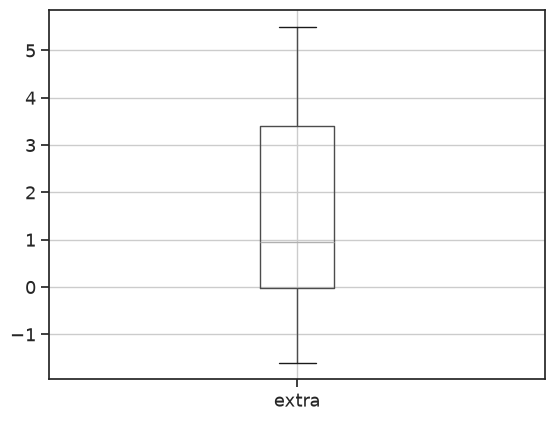

In [38]:
# Boxplot
datafile.boxplot(column="extra")

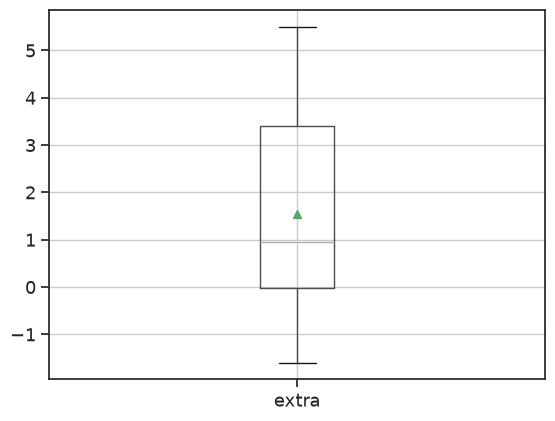

In [39]:
datafile.boxplot(
    column="extra",
    showmeans=True
)
plt.show()

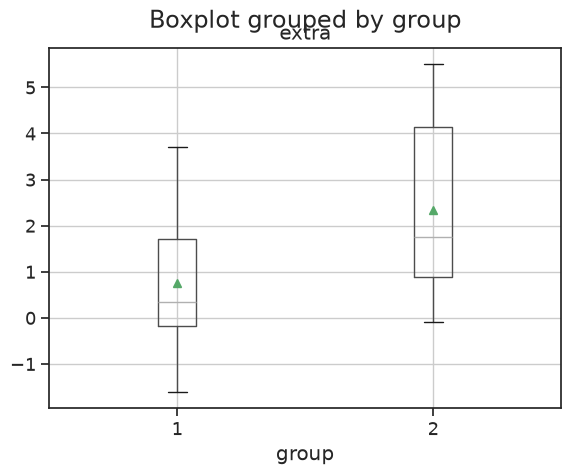

In [40]:
datafile.boxplot(column="extra", by="group", showmeans=True)
plt.show()

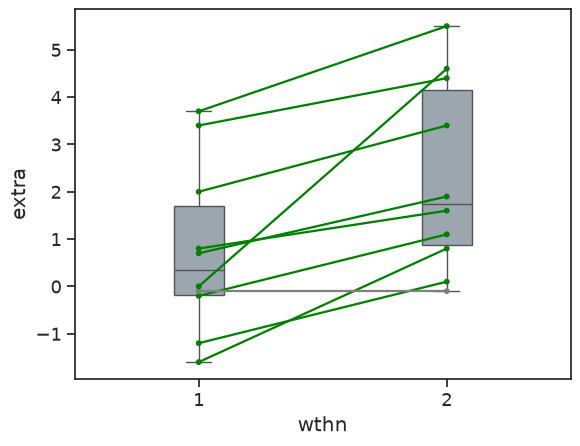

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
datafile=pd.read_csv ("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/sleep.csv")
#display (datafile.groupby('group').describe())
summary1 = (
    datafile.groupby("group")["extra"]
      .agg(
          mean="mean",
          std="std", #se=lambda x: x.sem(),
          #n="count"
      )
      .reset_index()
)
#print(summary)

#print (datafile["group"].dtype)
summary=datafile.groupby("group")["extra"].agg(["mean", "std"]).reset_index()
#summary["group"] = summary["group"].astype(str)
#plt.bar(summary["group"], summary["mean"], yerr=summary["std"], capsize=5)
#plt.xticks([1, 2], ["Control", "Treatment"])
#plt.ylabel("Extra Sleep (hours)")
#plt.show()
ax = pg.plot_paired(data=datafile, dv='extra', within='group', subject='ID') #, errorbar='se', pointplot=True, paired=True)


In [42]:
!mamba install pingouin

/bin/bash: line 1: mamba: command not found


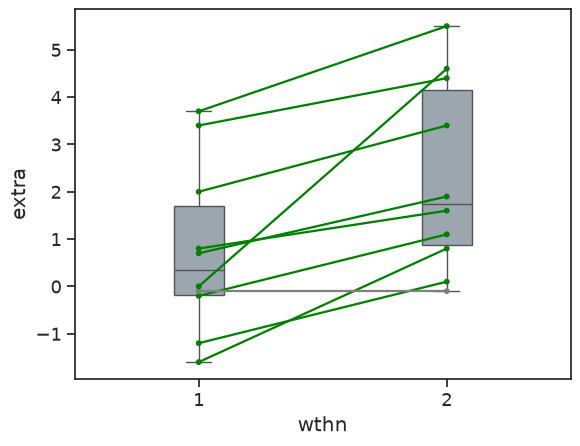

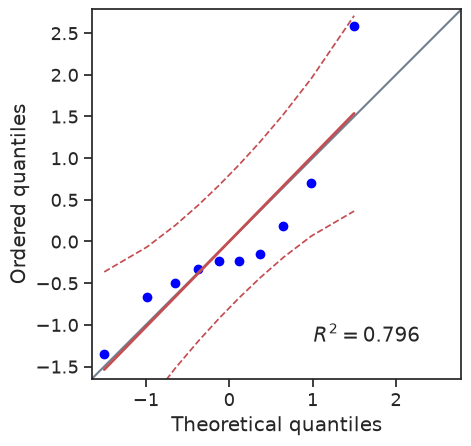

,W,pval,normal
0,0.829871,0.033342,False


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
# paired plot
pg.plot_paired(
    data=datafile,
    dv='extra',
    within='group',
    subject='ID'
)
plt.show()
# difference scores
wide = datafile.pivot(index='ID', columns='group', values='extra')
diff = wide[2] - wide[1]

# QQ plot
pg.qqplot(diff)
plt.show()

# Shapiro-Wilk
pg.normality(diff)

# paired t-test
#pg.ttest(wide[1], wide[2], paired=True)

Text(0.5, 1.0, 'Achieved power of a paired T-test')

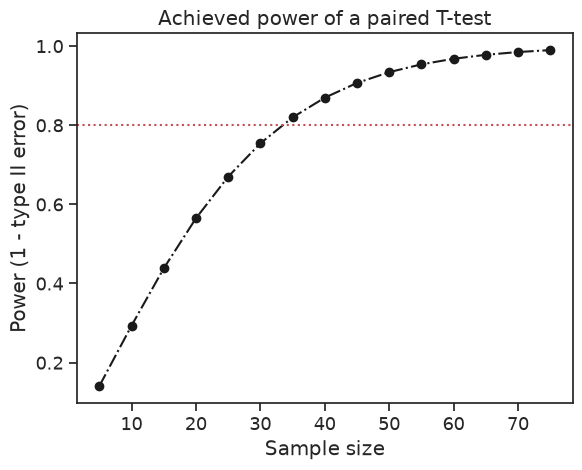

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import numpy as np
sns.set(style='ticks', context='notebook', font_scale=1.2)
d = 0.5  # Fixed effect size
n = np.arange(5, 80, 5)  # Incrementing sample size
# Compute the achieved power
pwr = pg.power_ttest(d=d, n=n, contrast='paired')
# Start the plot
plt.plot(n, pwr, 'ko-.')
plt.axhline(0.8, color='r', ls=':')
plt.xlabel('Sample size')
plt.ylabel('Power (1 - type II error)')
plt.title('Achieved power of a paired T-test')
# ax=plt.gca() ax.spines['top'].set_visible(False) sns.despine()

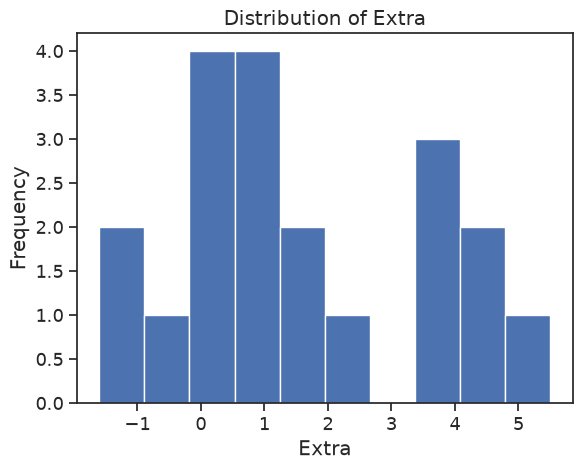

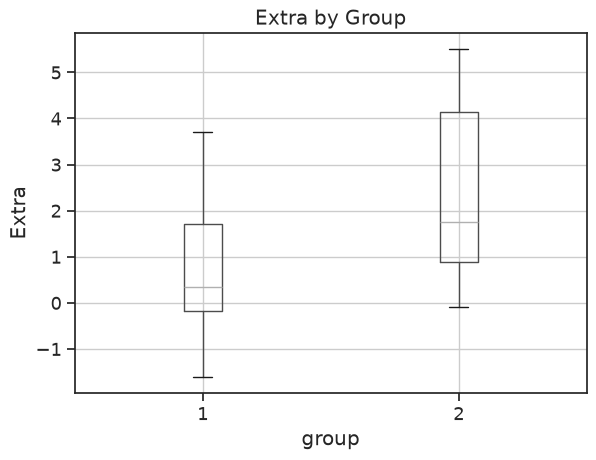

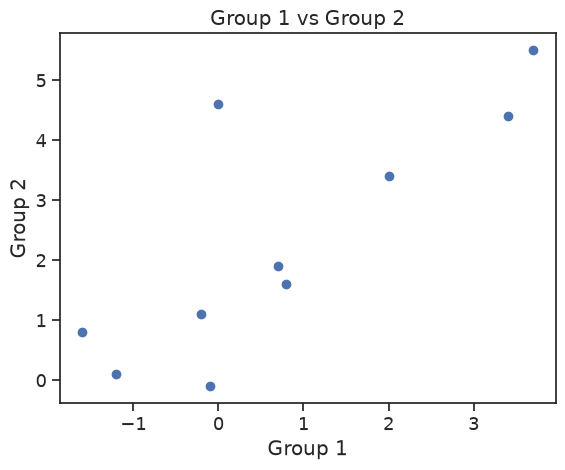

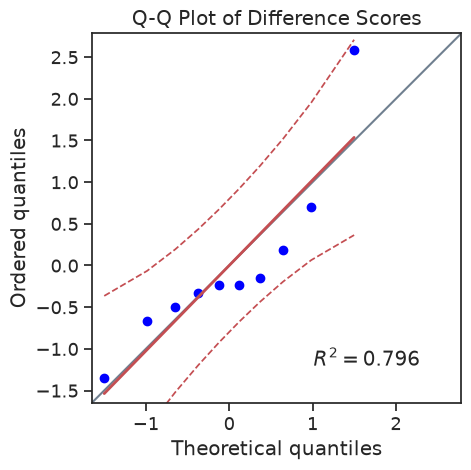

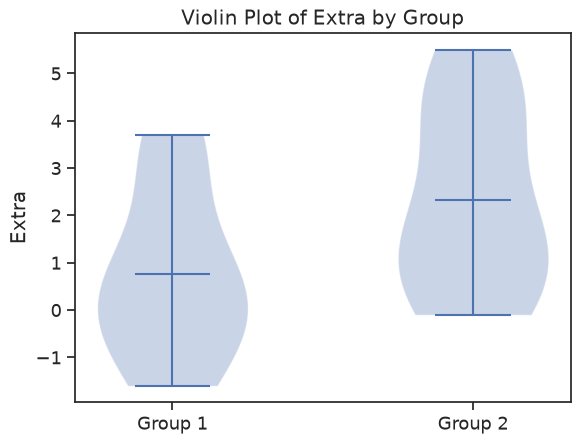

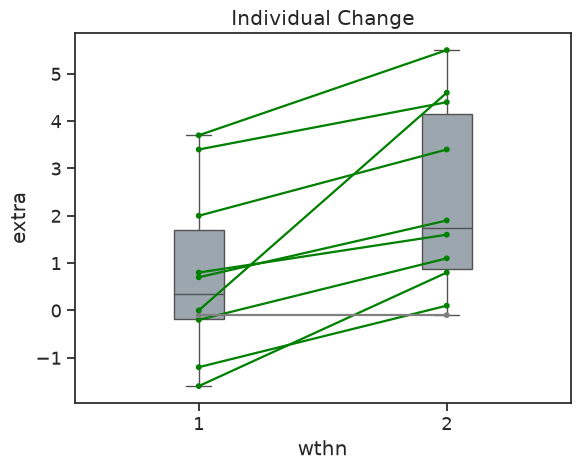

In [45]:
# ==========================================
# Paired Data Visualization Examples
# Variables:
# ID     = participant
# group  = 1 or 2 (paired conditions)
# extra  = outcome variable
# ==========================================

import matplotlib.pyplot as plt
import pingouin as pg
df = datafile.copy()
# ------------------------------------------
# 1. Histogram → distribution
# ------------------------------------------
plt.hist(df['extra'], bins=10)
plt.xlabel('Extra')
plt.ylabel('Frequency')
plt.title('Distribution of Extra')
plt.show()

# ------------------------------------------
# 2. Boxplot → spread & outliers
# ------------------------------------------
df.boxplot(column='extra', by='group')
plt.suptitle('')
plt.title('Extra by Group')
plt.ylabel('Extra')
plt.show()

# ------------------------------------------
# 3. Scatterplot → relationship
# ------------------------------------------
wide = df.pivot(index='ID', columns='group', values='extra')

plt.scatter(wide[1], wide[2])
plt.xlabel('Group 1')
plt.ylabel('Group 2')
plt.title('Group 1 vs Group 2')
plt.show()

# ------------------------------------------
# 4. Q-Q Plot → normality of differences
# ------------------------------------------
diff = wide[2] - wide[1]

pg.qqplot(diff)
plt.title('Q-Q Plot of Difference Scores')
plt.show()

# 4 b: violin for shape of the distribution, not just the median and quartiles.


data = [
    df.loc[df['group'] == 1, 'extra'],
    df.loc[df['group'] == 2, 'extra']
]

plt.violinplot(data, showmeans=True)

plt.xticks([1, 2], ['Group 1', 'Group 2'])
plt.ylabel('Extra')
plt.title('Violin Plot of Extra by Group')
plt.show()
# ------------------------------------------
# 5. Paired Plot → individual change
# ------------------------------------------
pg.plot_paired(
    data=df,
    dv='extra',
    within='group',
    subject='ID'
)

plt.title('Individual Change')
plt.show()

<Axes: xlabel='parent', ylabel='child'>

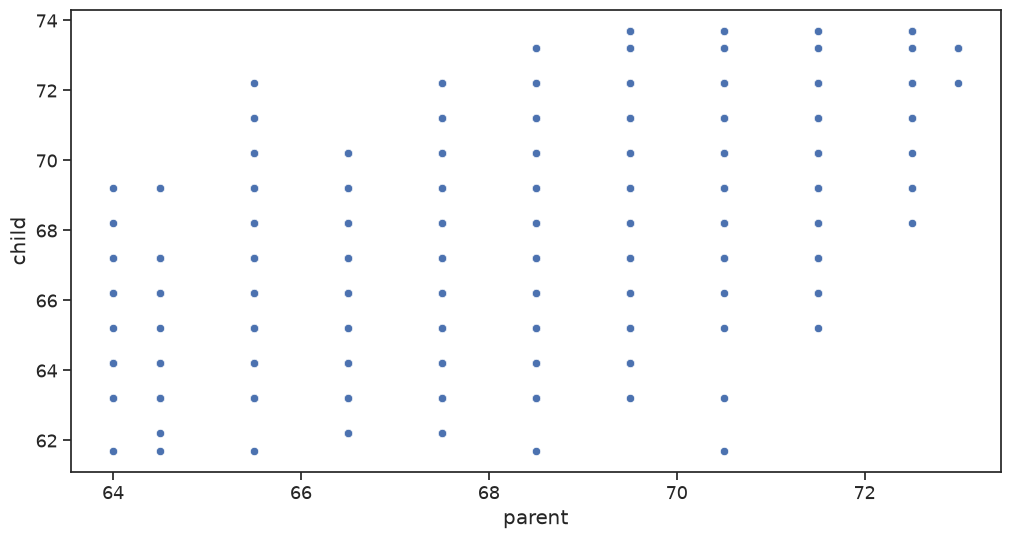

In [46]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

data = 'https://vincentarelbundock.github.io/Rdatasets/csv/HistData/Galton.csv'
df = pd.read_csv(data, index_col=0)

plt.figure(figsize=(12, 6))
sns.scatterplot(x='parent', y='child', data=df)

In [47]:
print("hello world")

hello world


In [48]:
import pandas as pd, pingouin as pg
nhanes=pd.read_csv("https://raw.githubusercontent.com/Psyc3000A/Data/refs/heads/main/nhanes.csv")
pg.chi2_independence(nhanes, x="HowOftenDoYouFeelDepressed", y="EverToldDoctorHadTroubleSleeping")

(EverToldDoctorHadTroubleSleeping          0.0         1.0
 HowOftenDoYouFeelDepressed                               
 0.0                               1866.324319  706.675681
 1.0                               1251.953274  474.046726
 2.0                                322.780537  122.219463
 3.0                                282.160964  106.839036
 4.0                                219.780905   83.219095,
 EverToldDoctorHadTroubleSleeping   0.0  1.0
 HowOftenDoYouFeelDepressed                 
 0.0                               2137  436
 1.0                               1236  490
 2.0                                264  181
 3.0                                199  190
 4.0                                107  196,
                  test    lambda        chi2  dof           pval    cramer  \
 0             pearson  1.000000  482.605128  4.0  3.872451e-103  0.297959   
 1        cressie-read  0.666667  470.001830  4.0  2.057373e-100  0.294042   
 2      log-likelihood  0.000000  45